<h1>Exploración de corpus</h1>


<h2>Corpus 1: RestMex2021</h2>


In [ ]:
!gdown

usage: gdown [-h] [-V] [-O OUTPUT] [-q] [--fuzzy] [--id] [--proxy PROXY]
             [--speed SPEED] [--no-cookies] [--no-check-certificate]
             [--continue] [--folder] [--remaining-ok] [--format FORMAT]
             [--user-agent USER_AGENT]
             url_or_id
gdown: error: the following arguments are required: url_or_id


Leemos el archivo `csv` con [pandas](https://pandas.pydata.org/docs/user_guide/index.html) en un [dataframe](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame)

In [ ]:
import pandas as pd

df = pd.read_csv('RestMex2021-train.csv')
df

,Unnamed: 0,Title,Opinion,Place,Gender,Age,Country,Date,Label
0,0,"""No es para recomendarse""","""Las famosas momias de Guanajuato. El museo en...",Museo de las Momias,Male,48,México,02/07/2013,0
1,1,"""Es un mercado tradicional, no es nada del otr...","""Allí puedes encontrar comida o souvenirs. Es ...",Mercado Hidalgo,Male,52,México,06/09/2016,0
2,2,"""No visitar""","""Es tardado entrar al museo, una vez dentro no...",Museo de las Momias,Male,42,México,25/12/2017,0
3,3,"""No le veo atractivo. A ver semejantes cacharros""","""Entiendo que a muchos les cautive o llamé la ...",Museo de las Momias,Female,24,México,14/08/2013,0
4,4,"""Nada fuera de lo común""","""La fruta y verdura son poco frescos, al igual...",Mercado Hidalgo,Female,19,México,01/08/2017,0
...,...,...,...,...,...,...,...,...,...
4412,4412,"""Beautiful architecture""","""This university is famous because of its beau...",Universidad de Guanajuato,Male,24,México,21/04/2014,1
4413,4413,"""Imponente la universidad, TODO guanajuato es ...","""Lo que no me gusto fue la comida, pero es muy...",Universidad de Guanajuato,Female,44,México,05/07/2015,1
4414,4414,Lugar magico,Esta excelente para pasar a sentarse unos minu...,Jardín de la Unión,Male,-1,México,2018,1
4415,4415,"""¡Su fachada es hermosa!""","""No tuvimos la fortuna de entrar a verlo, ya q...",Teatro Juárez,Female,47,México,22/10/2012,1


Nube de palabras etiquetado por títulos

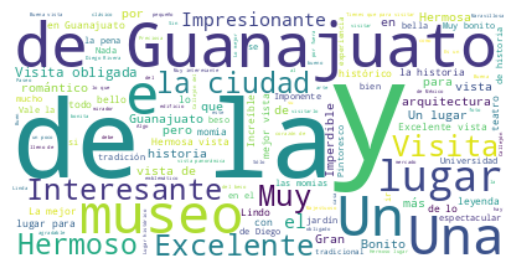

In [ ]:
import wordcloud
import matplotlib.pyplot as plt

text = " ".join(str(text) for text in df['Title'])

wc = wordcloud.WordCloud(background_color="white").generate(text)

plt.figure()
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.savefig("nube_palabras.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:

#Descarga de la imagen de la nube
from google.colab import files
files.download("nube_palabras.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Histograma de longitudes de documentos

In [ ]:
df["longitud_palabras"] = (
    df["Opinion"]
    .dropna()
    .str.split()
    .str.len()
)

In [ ]:
df

,Unnamed: 0,Title,Opinion,Place,Gender,Age,Country,Date,Label,longitud_palabras
0,0,"""No es para recomendarse""","""Las famosas momias de Guanajuato. El museo en...",Museo de las Momias,Male,48,México,02/07/2013,0,165.0
1,1,"""Es un mercado tradicional, no es nada del otr...","""Allí puedes encontrar comida o souvenirs. Es ...",Mercado Hidalgo,Male,52,México,06/09/2016,0,30.0
2,2,"""No visitar""","""Es tardado entrar al museo, una vez dentro no...",Museo de las Momias,Male,42,México,25/12/2017,0,51.0
3,3,"""No le veo atractivo. A ver semejantes cacharros""","""Entiendo que a muchos les cautive o llamé la ...",Museo de las Momias,Female,24,México,14/08/2013,0,43.0
4,4,"""Nada fuera de lo común""","""La fruta y verdura son poco frescos, al igual...",Mercado Hidalgo,Female,19,México,01/08/2017,0,18.0
...,...,...,...,...,...,...,...,...,...,...
4412,4412,"""Beautiful architecture""","""This university is famous because of its beau...",Universidad de Guanajuato,Male,24,México,21/04/2014,1,29.0
4413,4413,"""Imponente la universidad, TODO guanajuato es ...","""Lo que no me gusto fue la comida, pero es muy...",Universidad de Guanajuato,Female,44,México,05/07/2015,1,28.0
4414,4414,Lugar magico,Esta excelente para pasar a sentarse unos minu...,Jardín de la Unión,Male,-1,México,2018,1,17.0
4415,4415,"""¡Su fachada es hermosa!""","""No tuvimos la fortuna de entrar a verlo, ya q...",Teatro Juárez,Female,47,México,22/10/2012,1,55.0


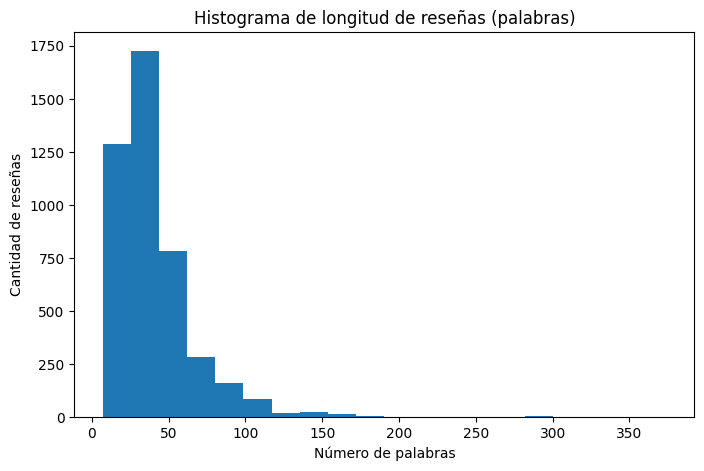

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["longitud_palabras"], bins=20)
plt.title("Histograma de longitud de reseñas (palabras)")
plt.xlabel("Número de palabras")
plt.ylabel("Cantidad de reseñas")
plt.show()


Observación de los lugares de procedencia de las personas de los documentos

In [ ]:
palabras = (
    df["Opinion"]
    .dropna()
    .str.lower()
    .str.split()
    .explode()
)


conteo_paises = df["Country"].value_counts()
conteo_paises


,count
Country,
México,3434
Argentina,176
Colombia,104
N/I,103
Estados Unidos,94
España,83
Chile,80
Perú,56
Costa Rica,41


Top 10 palabras más usadas

In [ ]:
conteo = palabras.value_counts()
conteo.head(10)


,count
Opinion,
de,9689
la,7136
y,5710
que,5578
es,3898
en,3832
el,3757
un,2738
a,2633


Analisis por categoría

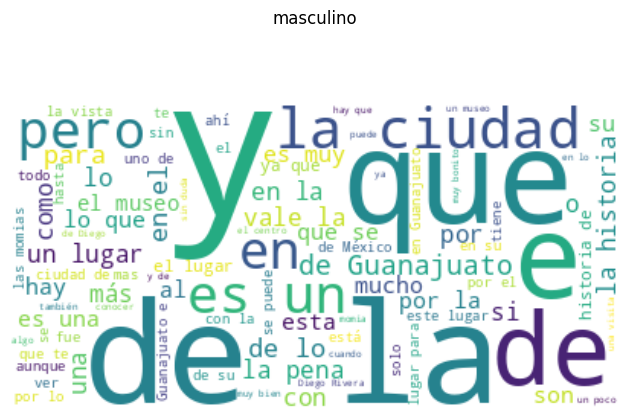

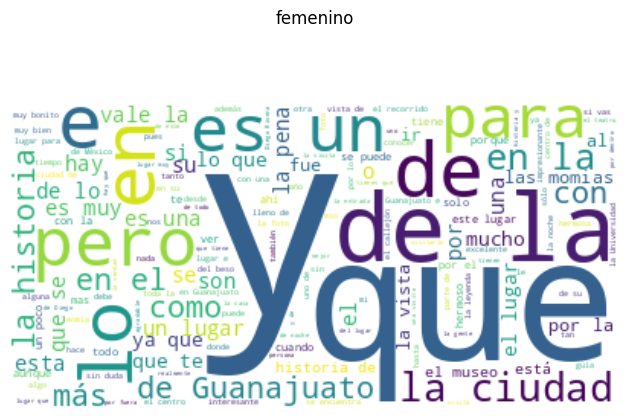

In [ ]:
import wordcloud
import matplotlib.pyplot as plt

male_df = df[df['Gender']=='Male'].copy()
female_df = df[df['Gender']=='Female'].copy()
dfs = [male_df, female_df]

for x,label in zip(dfs,['masculino','femenino']):
    text = " ".join(str(text) for text in x['Opinion'])
    wc = wordcloud.WordCloud(background_color="white").generate(text)
    plt.figure()
    plt.suptitle(label)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd

topics_df = pd.read_csv('RestMex2021-train.csv')
topics_df

,Unnamed: 0,Title,Opinion,Place,Gender,Age,Country,Date,Label
0,0,"""No es para recomendarse""","""Las famosas momias de Guanajuato. El museo en...",Museo de las Momias,Male,48,México,02/07/2013,0
1,1,"""Es un mercado tradicional, no es nada del otr...","""Allí puedes encontrar comida o souvenirs. Es ...",Mercado Hidalgo,Male,52,México,06/09/2016,0
2,2,"""No visitar""","""Es tardado entrar al museo, una vez dentro no...",Museo de las Momias,Male,42,México,25/12/2017,0
3,3,"""No le veo atractivo. A ver semejantes cacharros""","""Entiendo que a muchos les cautive o llamé la ...",Museo de las Momias,Female,24,México,14/08/2013,0
4,4,"""Nada fuera de lo común""","""La fruta y verdura son poco frescos, al igual...",Mercado Hidalgo,Female,19,México,01/08/2017,0
...,...,...,...,...,...,...,...,...,...
4412,4412,"""Beautiful architecture""","""This university is famous because of its beau...",Universidad de Guanajuato,Male,24,México,21/04/2014,1
4413,4413,"""Imponente la universidad, TODO guanajuato es ...","""Lo que no me gusto fue la comida, pero es muy...",Universidad de Guanajuato,Female,44,México,05/07/2015,1
4414,4414,Lugar magico,Esta excelente para pasar a sentarse unos minu...,Jardín de la Unión,Male,-1,México,2018,1
4415,4415,"""¡Su fachada es hermosa!""","""No tuvimos la fortuna de entrar a verlo, ya q...",Teatro Juárez,Female,47,México,22/10/2012,1


Pequeña muestra sobre la temática del texto

In [ ]:
from numpy.random import rand
import numpy as np

random_idxs = np.random.choice(len(topics_df), 3)

for k in random_idxs:
    print(topics_df.iloc[k]['Opinion'])
    print(50*"=")

Viajar con tu pareja significa en sí un acto de amor. Compartir,
disfrutar y admirar conlleva ya la experiencia de vivir un momento único, y es justo eso lo que aporta la visita al 
Callejón del Beso, un lugar súper emblemático en Guanajuato.
Visitar este lugar reafirma el compromiso simbólico con tu 
pareja y la esperanza de lo que esperan para el futuro. Por
supuesto, el beso en el tercer escalón y la selfie es más que
obligado. Existe la posibilidad de subir al balcón para tomarse 
una foto y el costo del acceso es de 20 pesos, pero si la fila es
larga sugiero no perder el tiempo formándose y mejor invertirlo
en seguir subiendo por los callejones del Venado, Calixto y la
subida de San Miguel para disfrutar de la mejor panorámica
de la ciudad desde el Monumento al Pípila, La subida es
bastante pesada y hasta puedes jugar a ver quién tiene la peor
condicón, pero la recompensa de pasarla juntos en el mirador de verdad vale la pena.
"Más allá de la arquitectura, que es muy bella (especi

In [ ]:
topics_df.dropna(inplace=True)

Nube de palabras de Opinion

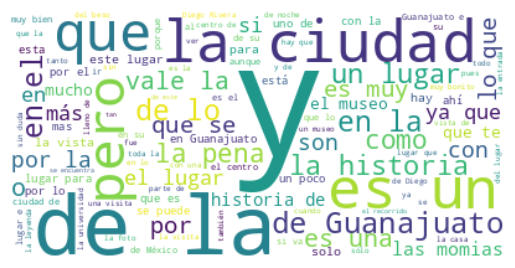

In [ ]:
import wordcloud
import matplotlib.pyplot as plt

text = " ".join(text for text in topics_df['Opinion'])

wc = wordcloud.WordCloud(background_color="white").generate(text)

plt.figure()
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

<h2>Corpus 2: cnn</h2>

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
!python -m pip install gdown

In [ ]:
!gdown 1S-KYaCpb39vMphrkdnceXUkUhzHeapt7

Downloading...
From (original): https://drive.google.com/uc?id=1S-KYaCpb39vMphrkdnceXUkUhzHeapt7
From (redirected): https://drive.google.com/uc?id=1S-KYaCpb39vMphrkdnceXUkUhzHeapt7&confirm=t&uuid=84057c30-ce80-4f44-b5b5-23ffe4f82a18
To: /content/cnn_articles.txt
100% 365M/365M [00:04<00:00, 82.1MB/s]


In [ ]:
!pip install pandas

In [ ]:
import os
import pandas as pd

file_path = os.path.join(
    os.path.expanduser("~"),
    "Downloads",
    "cnn_articles.txt"
)

with open(file_path, "r", encoding="utf-8") as f:
    raw_text = f.read()

blocks = raw_text.split("@delimiter")

news = []

for block in blocks:
    block = block.strip()

    if block:
        news.append(block)

df = pd.DataFrame(
    {
        "News": news
    }
)

FileNotFoundError: [Errno 2] No such file or directory: '/root/Downloads/cnn_articles.txt'

In [ ]:
for k in range(5):
    print(df.iloc[k]['News'])
    print("\n\n")
    print(150*"=")
    print("\n\n")

-- Children in war-ravaged Afghanistan are safer than those growing up in London or New York, NATO's top civilian envoy says.

Mark Sedwill, the senior civilian representative for NATO, made the comments on an episode of CBBC's "Newsround," which is airing Monday.

In the show -- a BBC current-affairs program for children -- several youngsters in Kabul, Afghanistan, say they are afraid of daily violence and the frequent explosions in their war-torn country.

In response, Sedwill says: "Here in Kabul, and other big cities actually, there are very few of these bombs. The children are probably safer here than they would be in London, New York or Glasgow or many other cities.

"Most children can go about their lives in safety. It's a very family-oriented society. So it is a little bit like a city of villages," he added.

A U.N. report released earlier this year seems to contradict Sedwill's assessment.

The February report, by the special representative for children and armed conflict, say

In [ ]:
df

<h3>Nube de palabras</h3>

In [ ]:
!pip install matplotlib wordcloud

In [ ]:
import wordcloud
import matplotlib.pyplot as plt

text = " ".join(str(text) for text in df['News'])

wc = wordcloud.WordCloud(background_color="white").generate(text)

plt.figure()
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.savefig("cnn_clowd.png", dpi=1200, bbox_inches="tight")
plt.show()

<h3>Histograma de longitudes de documentos</h3>

In [ ]:
df["news_words"] = df["News"].str.findall(r"\b\w+\b").str.len()

In [ ]:
for k in range(20):
    print(df.iloc[k]['news_words'])
    print("\n")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["news_words"], bins=20)
plt.title("Histograma de longitud de noticias")
plt.xlabel("Número de palabras por noticia")
plt.ylabel("Cantidad de palabras")
plt.show()


<h3>Promedio de longitud por documento</h3>

In [ ]:
words_mean = df["news_words"].mean()
print(f"Media de palabras por documento: {words_mean}")

<h3>Top 10 palabras más usadas</h3>

In [ ]:
import re
from collections import Counter

# 1. Unir todas las noticias en un solo texto
all_text = " ".join(df["News"].dropna())

# 2. Extraer palabras (solo letras y números)
words = re.findall(r"\b\w+\b", all_text.lower())

# 3. Contar frecuencias
word_counts = Counter(words)

# 4. Obtener las 10 más usadas
top_10 = word_counts.most_common(10)

top_10


<h3>Longitud del vocabulario</h3>

In [ ]:
import re

# Unir todas las noticias
all_text = " ".join(df["News"].dropna())

# Extraer palabras normalizadas
words = re.findall(r"\b\w+\b", all_text.lower())

# Conjunto de palabras únicas
unique_words = set(words)

# Número de palabras únicas
num_unique_words = len(unique_words)

In [ ]:
print(f"Número de palabras únicas: {num_unique_words}")

<h3>Densidad léxica calculada: (palabras únicas / palabras totales) x 100</h3>



In [ ]:
print(f"Número de palabras totales: {len(words)}")
print(f"Número de palabras únicas: {num_unique_words}")
print(f"Densidad léxica: {(num_unique_words / len(words)) * 100}")